# Deliverable 1

## Phase 1: Data Preprocessing

### Data Loading

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('crop_recommendation.csv')

### Data Exploration

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### Data Cleaning

In [ ]:
duplicates = df[df.duplicated()]
duplicates

Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


In [ ]:
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64

In [ ]:
# 1. Find outliers using Z-score (threshold = 3)
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers_mask = z_scores > 3

print("\nOutliers mask (True indicates outlier):")
print(outliers_mask)

# 2. Show rows containing outliers
outlier_rows = df[outliers_mask.any(axis=1)]
print("\nRows containing outliers:")
print(outlier_rows)

# 3. Remove outliers (modify original DataFrame)
df = df[~outliers_mask.any(axis=1)]

print("\nDataFrame after removing outliers:")
print(df)


Outliers mask (True indicates outlier):
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]

Rows containing outliers:
       N   P   K  temperature   humidity        ph    rainfall   label
6     69  55  38    22.708838  82.639414  5.700806  271.324860    rice
12    78  58  44    26.800796  80.886848  5.108682  284.436457    rice
16    85  38  41    21.587118  82.788371  6.249051  276.655246    rice
19    88  35  40    23.579436  83.587603  5.853932  291.298662    rice
26    97  59  43    26.359272  84.044036  6.286500  271.358614    rice
...   ..  ..  ..          ...        ...       ...         ...     ...
1758  40  49  47    42.933686  91.175675  6.501521  246.361327  papaya
1761  59  62  49    43.360515  93.351916  6.941497  114.778071  papaya
1766  63  58  50    43.037143

TO REMOVE OUTLIERS 

In [ ]:
# If you want different thresholds for different columns
threshold = 1.5

# Create mask for outliers
outliers_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
columns = ['N','P','K','temperature','humidity','ph','rainfall']

for col in columns:
    if col in df.columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers_mask[col] = z_scores > threshold

# Remove outliers (modify original DataFrame)
df = df[~outliers_mask.any(axis=1)]

LABEL ENCODING 

In [ ]:
df['label'].unique()

array(['maize', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram',
       'lentil', 'pomegranate', 'banana', 'mango', 'watermelon',
       'muskmelon', 'orange', 'papaya', 'coconut', 'cotton', 'jute',
       'coffee'], dtype=object)

In [ ]:
le = LabelEncoder()

In [ ]:
df['label_encoded'] = le.fit_transform(df['label'])

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
100,71,54,16,22.613600,63.690706,5.749914,87.759539,maize,7
101,61,44,17,26.100184,71.574769,6.931757,102.266244,maize,7
102,80,43,16,23.558821,71.593514,6.657965,66.719955,maize,7
103,73,58,21,19.972160,57.682729,6.596061,60.651715,maize,7
105,68,41,16,21.776893,57.808406,6.158831,102.086169,maize,7


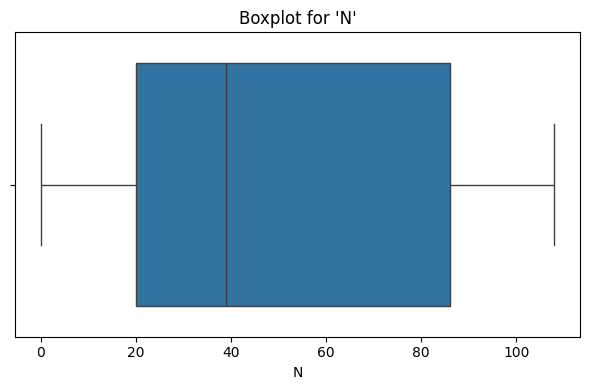

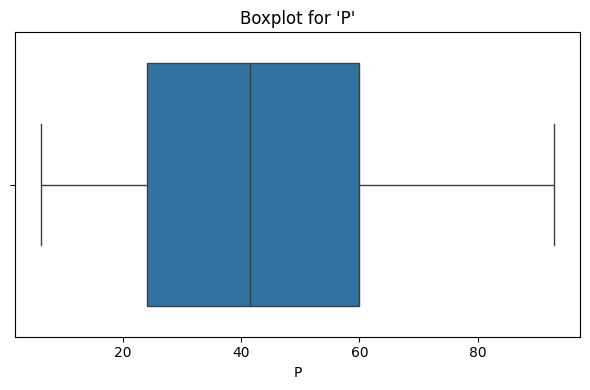

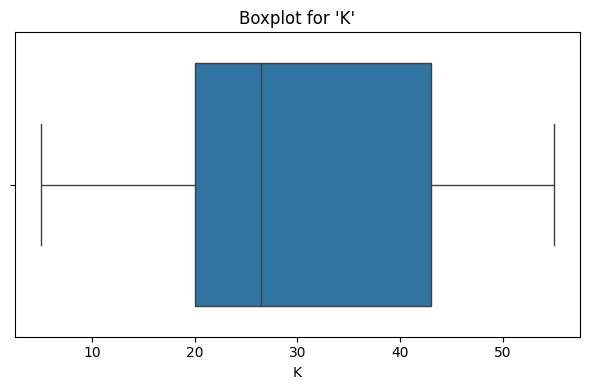

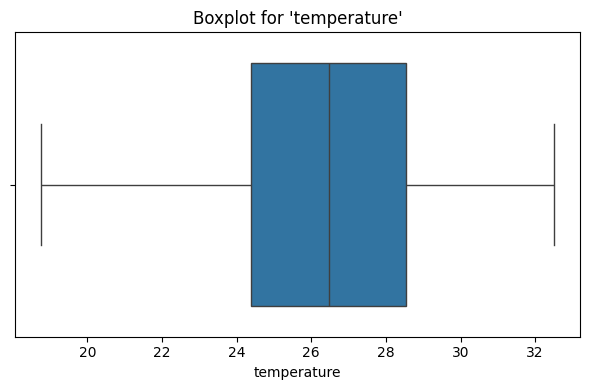

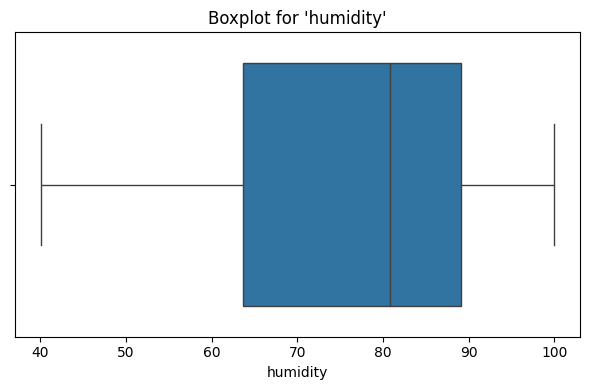

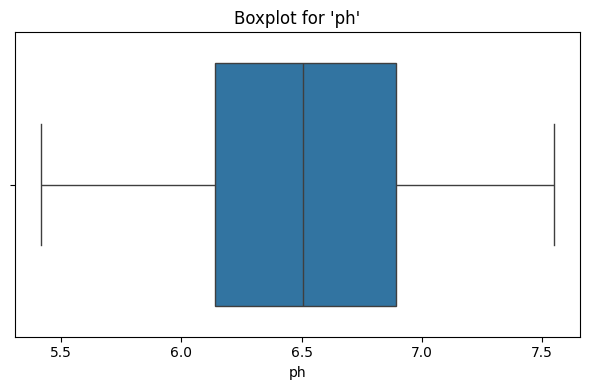

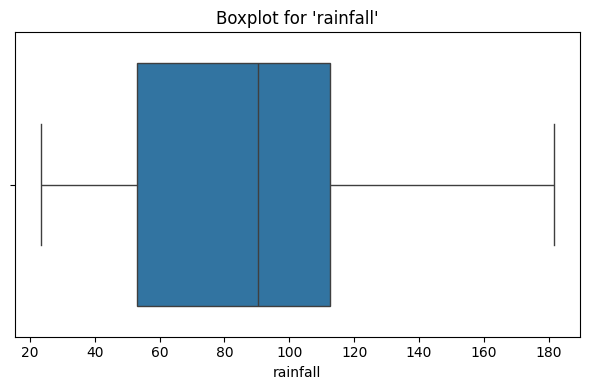

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Loop and plot each boxplot separately
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for '{col}'")
    plt.tight_layout()
    plt.show()

STANDARIZATION AND NORMALIZATION OF DATA 

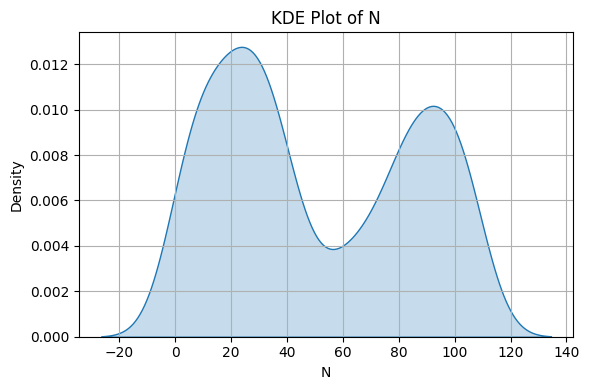

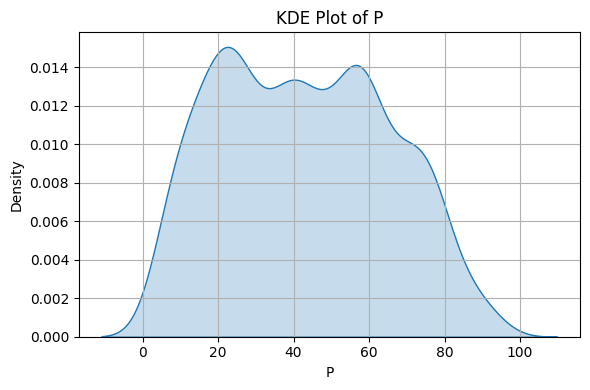

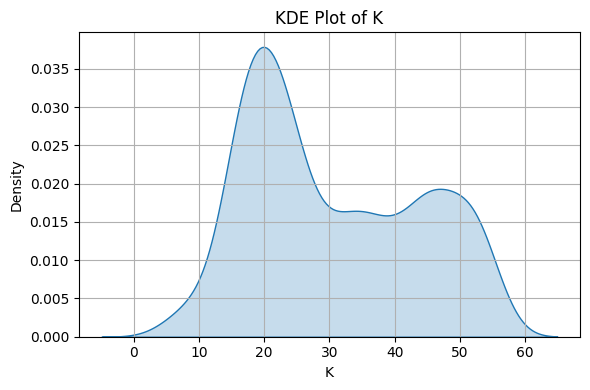

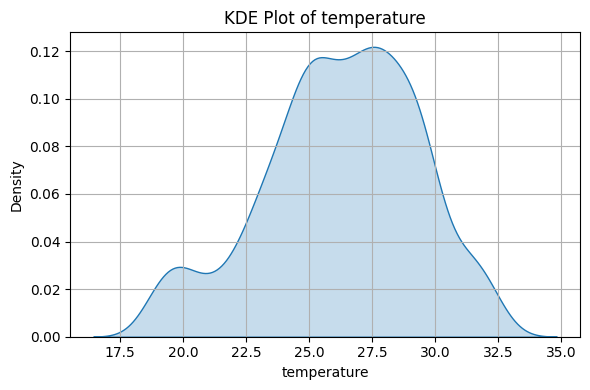

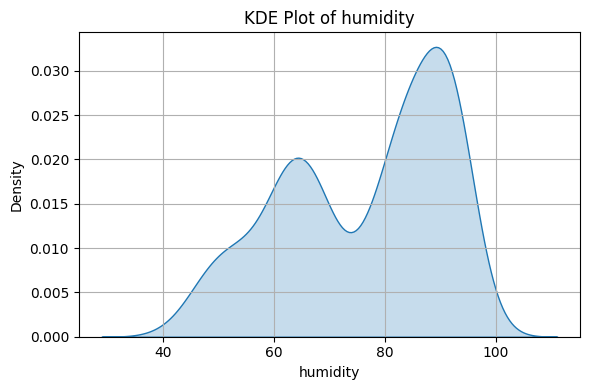

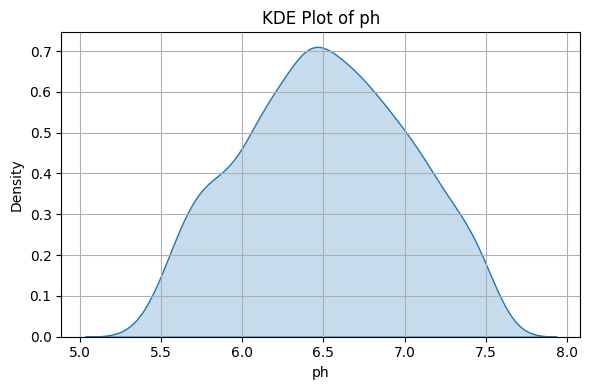

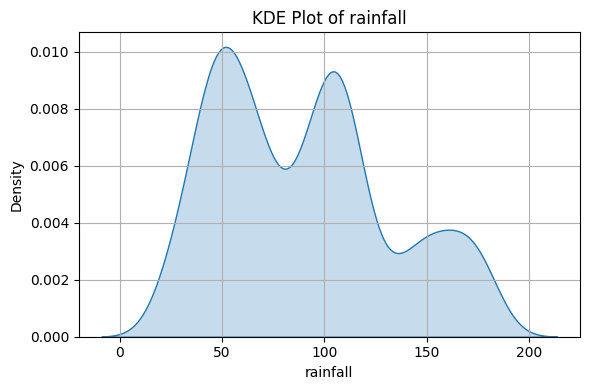

In [ ]:
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

NORMALIZING N through QuantileTransformer as it has 2 peaks 

In [ ]:
qt = QuantileTransformer(output_distribution='normal')  # or 'uniform'
df["N"] = qt.fit_transform(df[['N']])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (982). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: xlabel='N', ylabel='Density'>

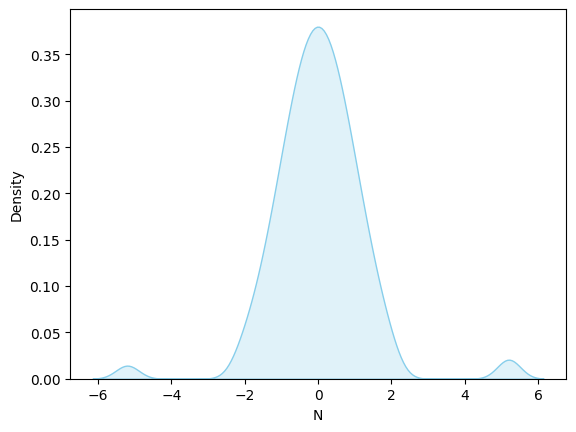

In [ ]:
sns.kdeplot(data=df, x="N", fill=True, color='skyblue')

In [ ]:
qt = QuantileTransformer(output_distribution='normal')  # Try 'uniform' too
df["P"] = qt.fit_transform(df[["P"]])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (982). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: xlabel='P', ylabel='Density'>

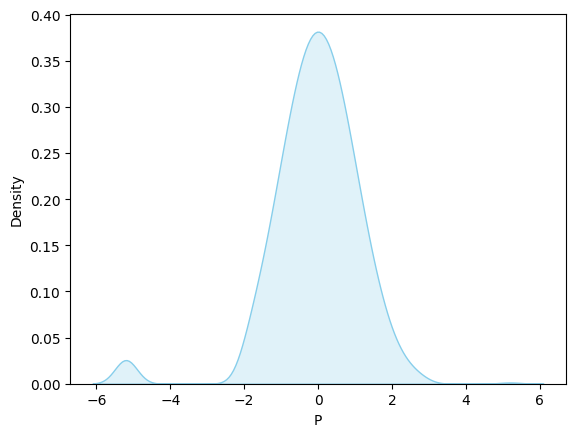

In [ ]:
sns.kdeplot(data=df, x="P", fill=True, color='skyblue')

In [ ]:
scaler = StandardScaler()
df['K'] = scaler.fit_transform(df[['K']])

<Axes: xlabel='K', ylabel='Density'>

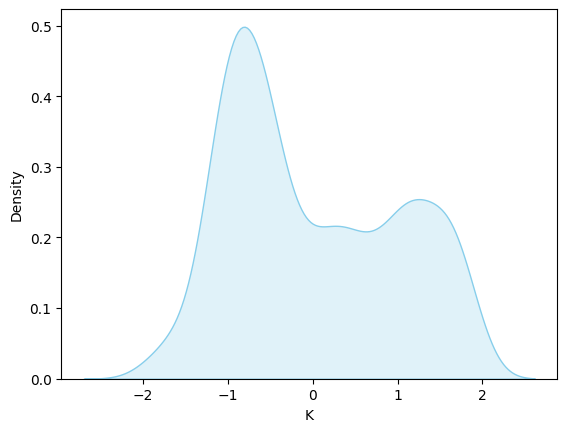

In [ ]:
sns.kdeplot(data=df, x="K", fill=True, color='skyblue')

In [ ]:
scaler = StandardScaler()
df['temperature'] = scaler.fit_transform(df[['temperature']])

In [ ]:
scaler = StandardScaler()
df['humidity'] = scaler.fit_transform(df[['humidity']])

In [ ]:
scaler = StandardScaler()
df['ph'] = scaler.fit_transform(df[['ph']])

In [ ]:
scaler = StandardScaler()
df['rainfall'] = scaler.fit_transform(df[['rainfall']])

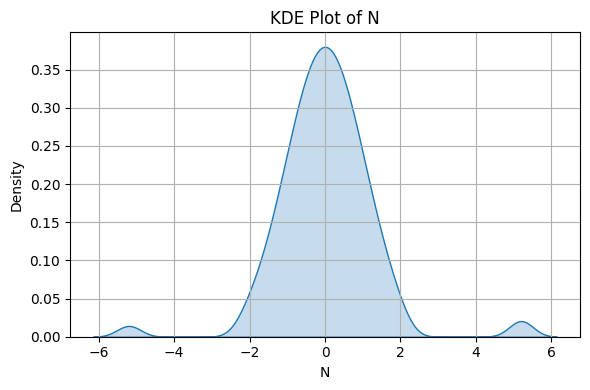

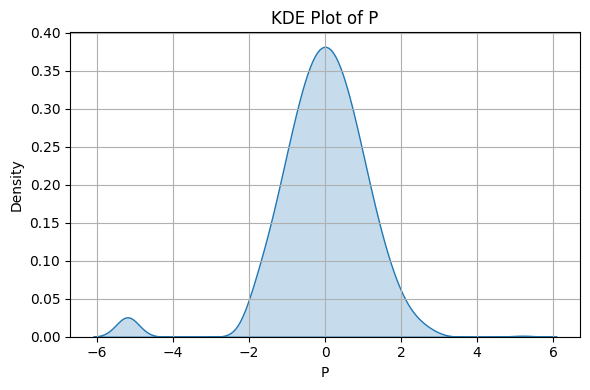

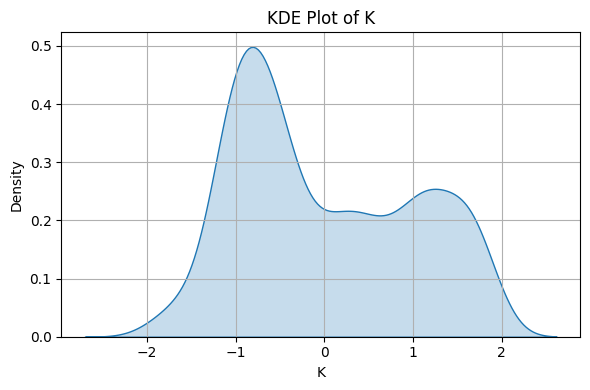

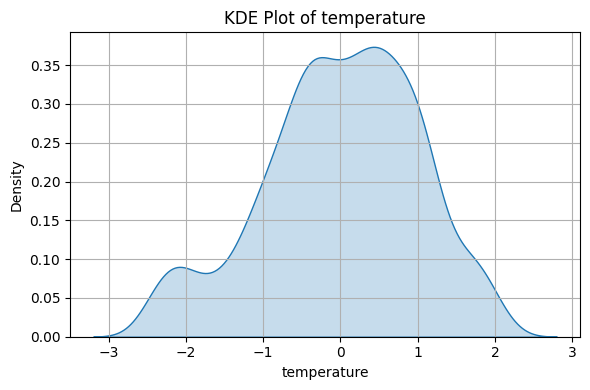

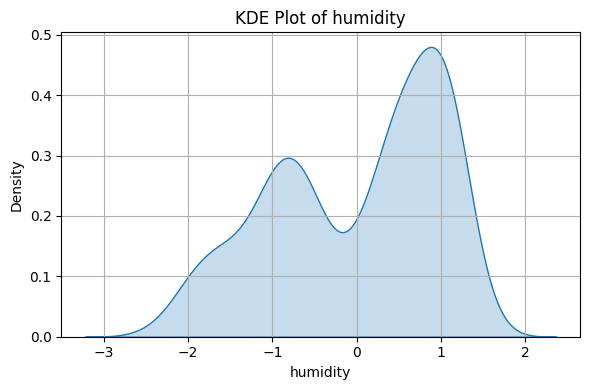

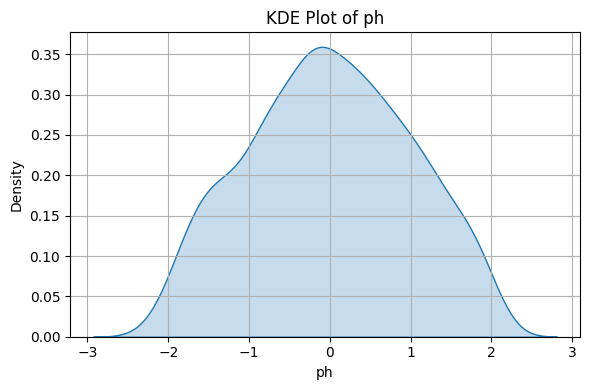

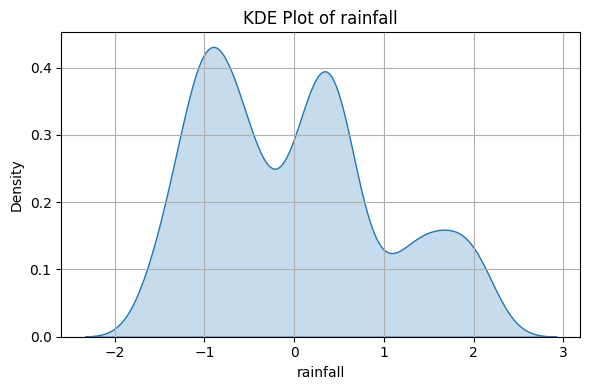

In [ ]:
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Phase 2: Exploratory Data Analysis (EDA)

###  Univariate Analysis

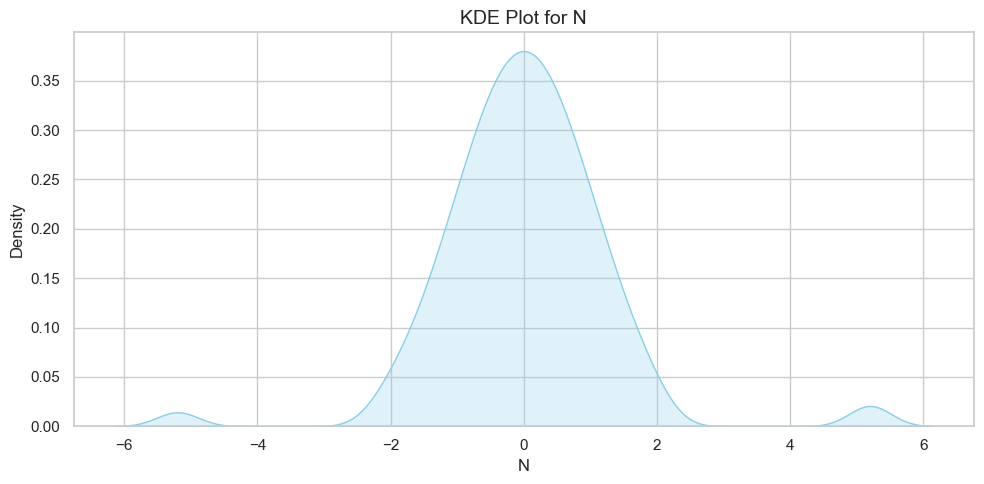

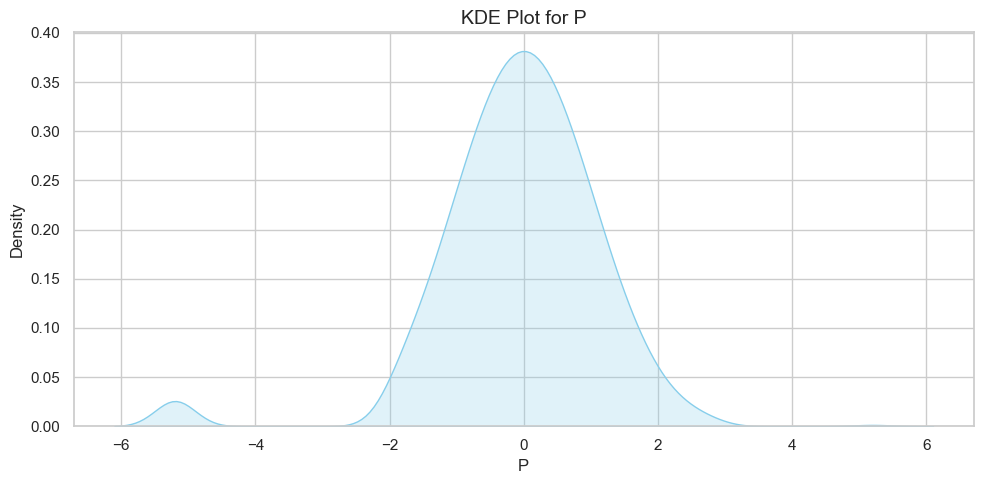

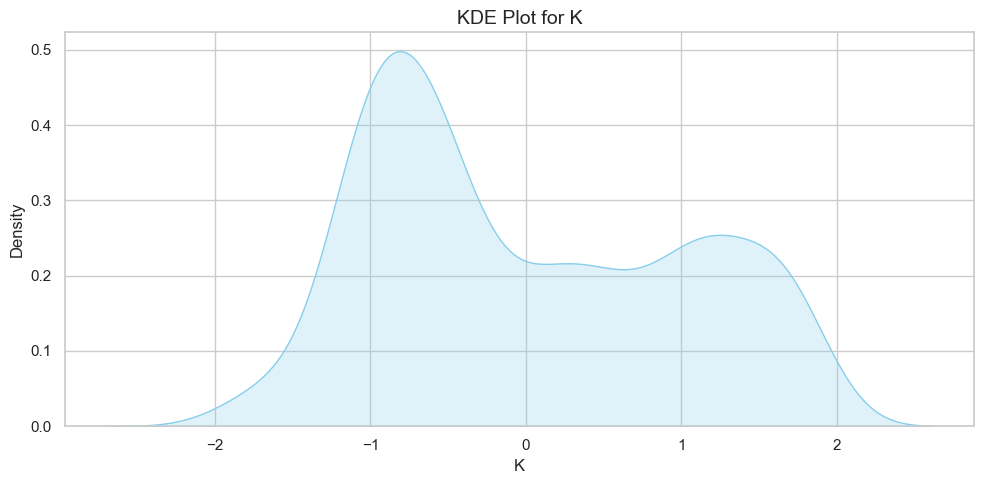

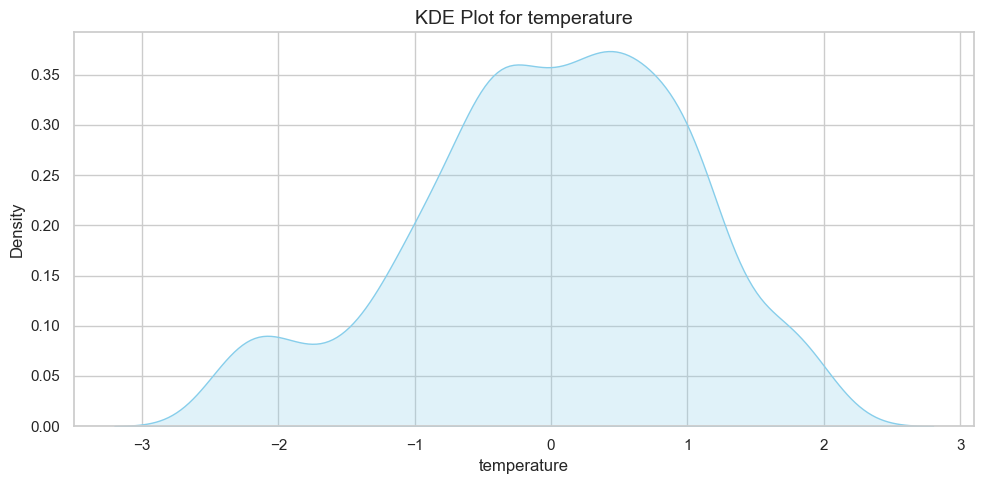

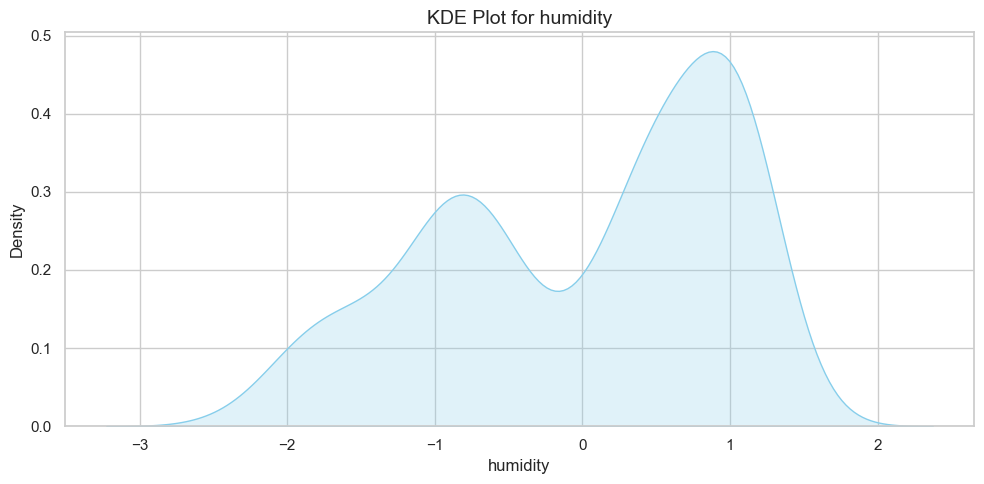

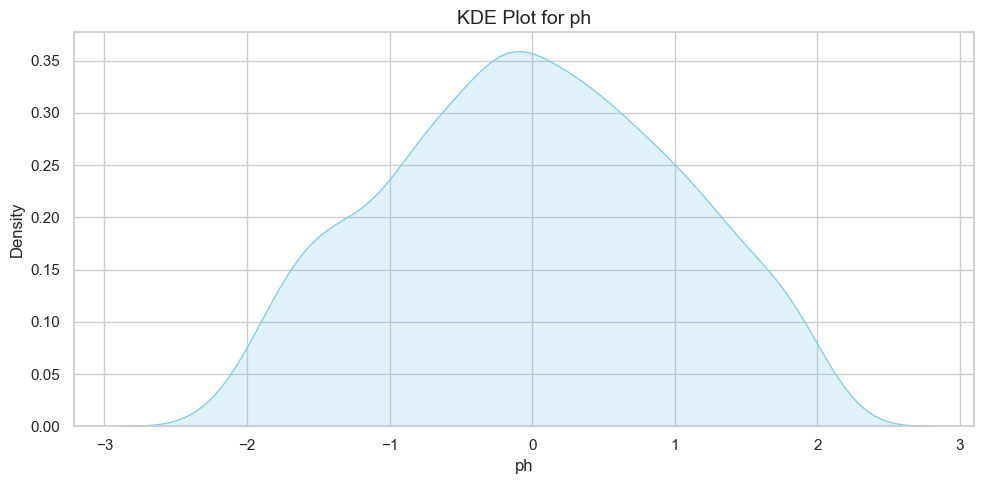

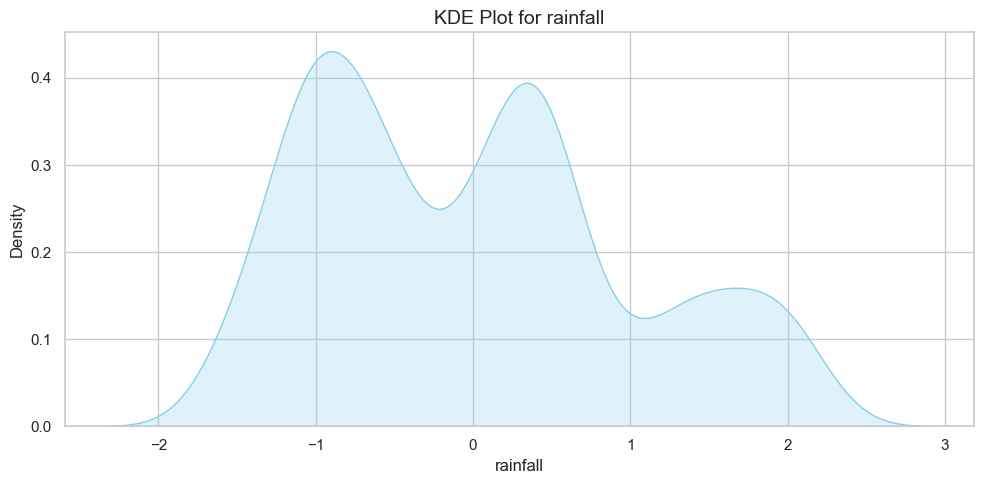

In [ ]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Identify numeric (continuous) columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot KDE plots for each continuous feature
for col in columns:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x=col, fill=True, color='skyblue')
    plt.title(f'KDE Plot for {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


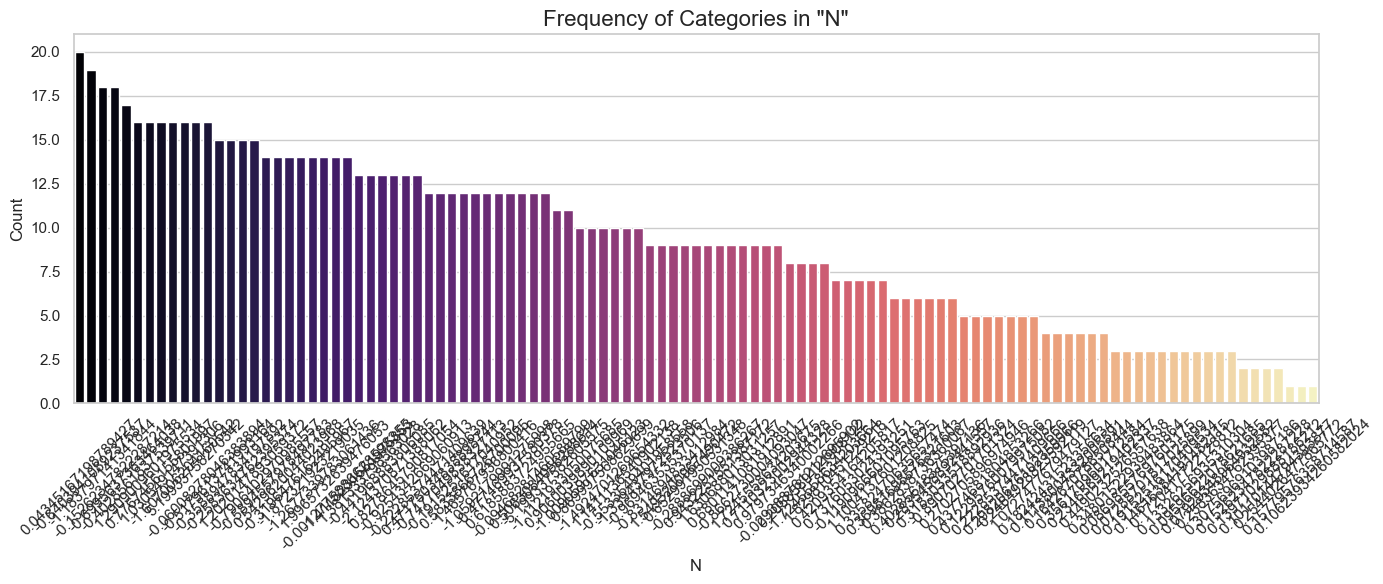

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


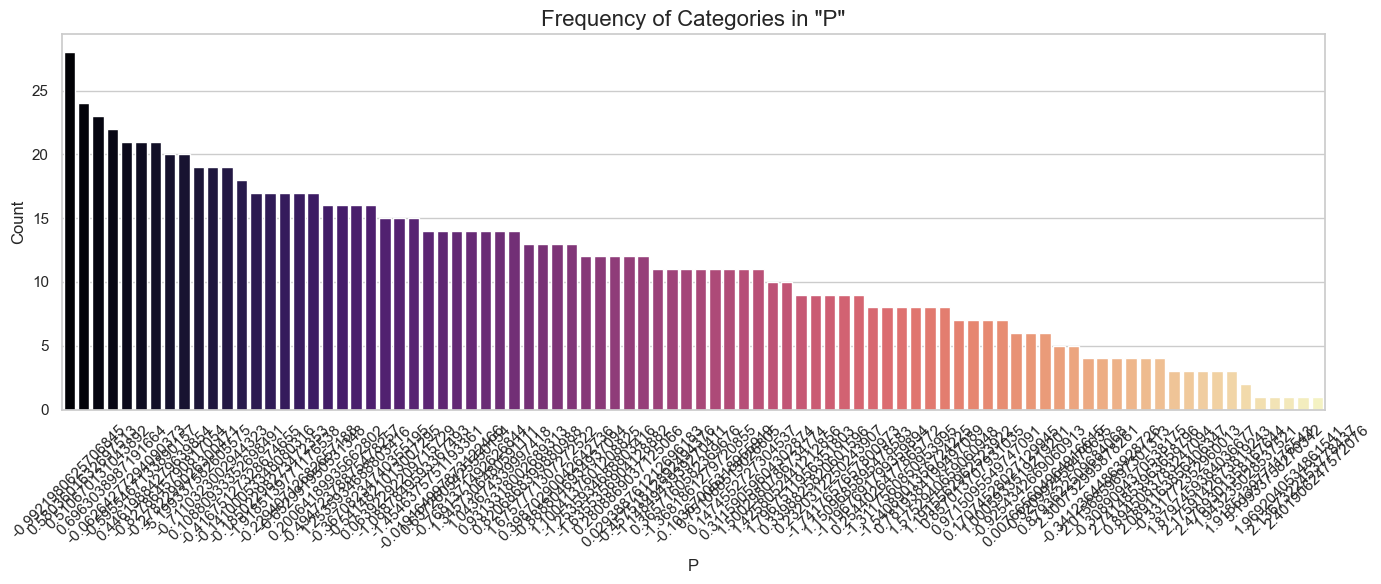

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


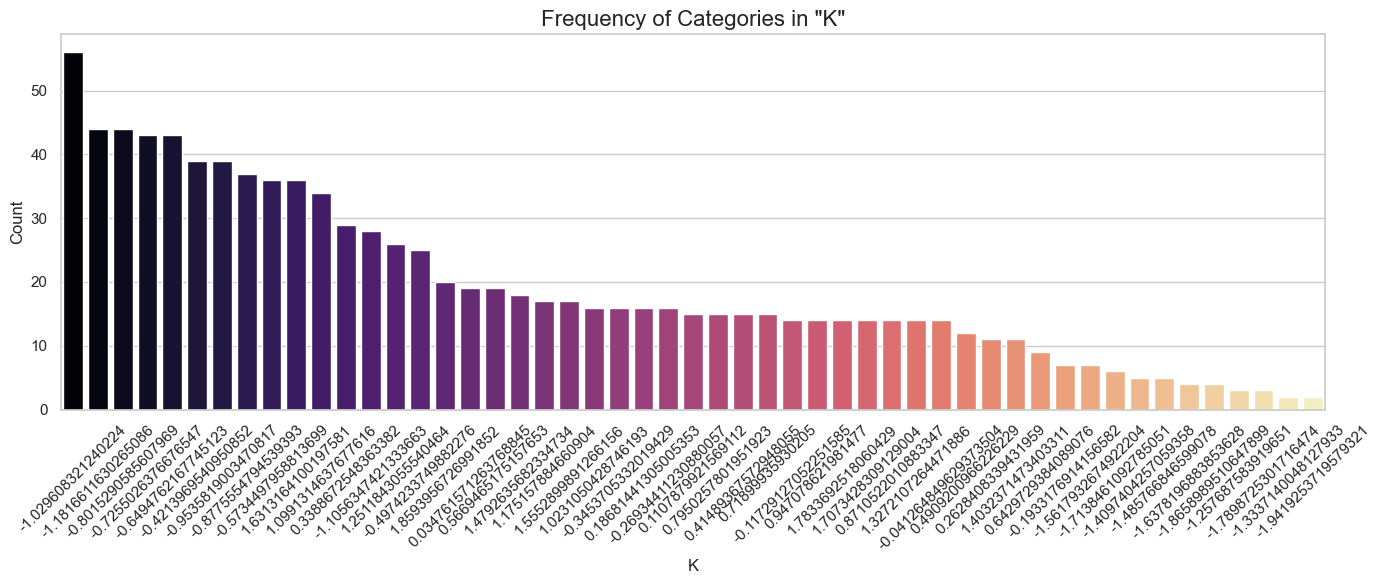

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


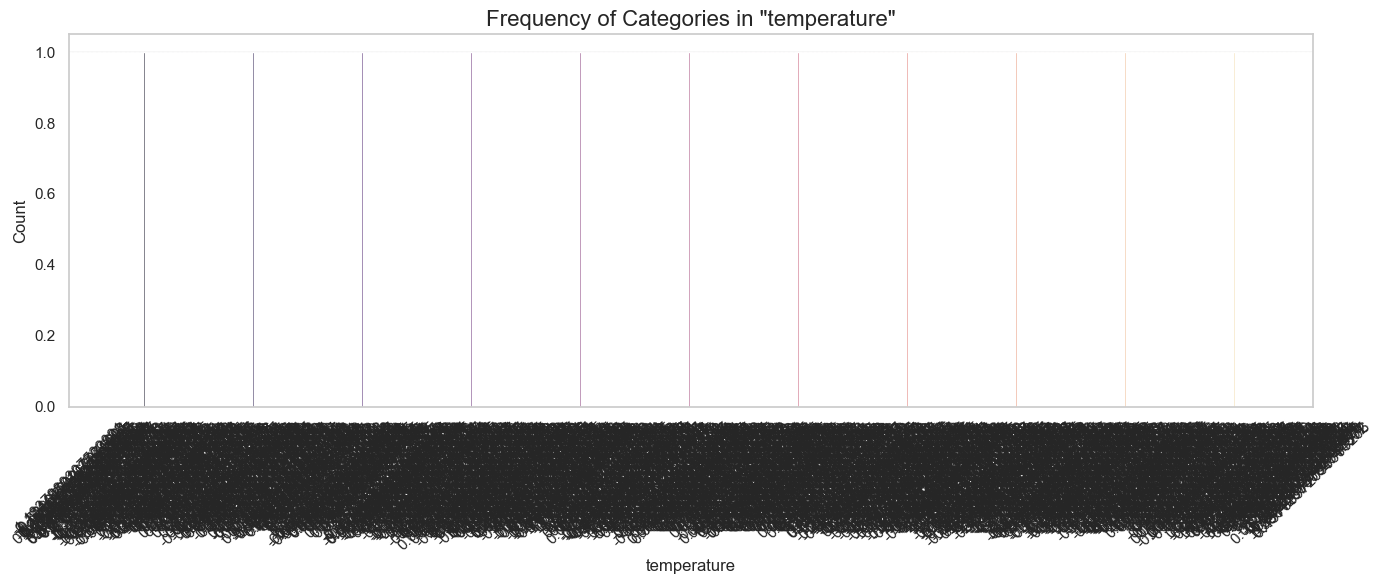

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


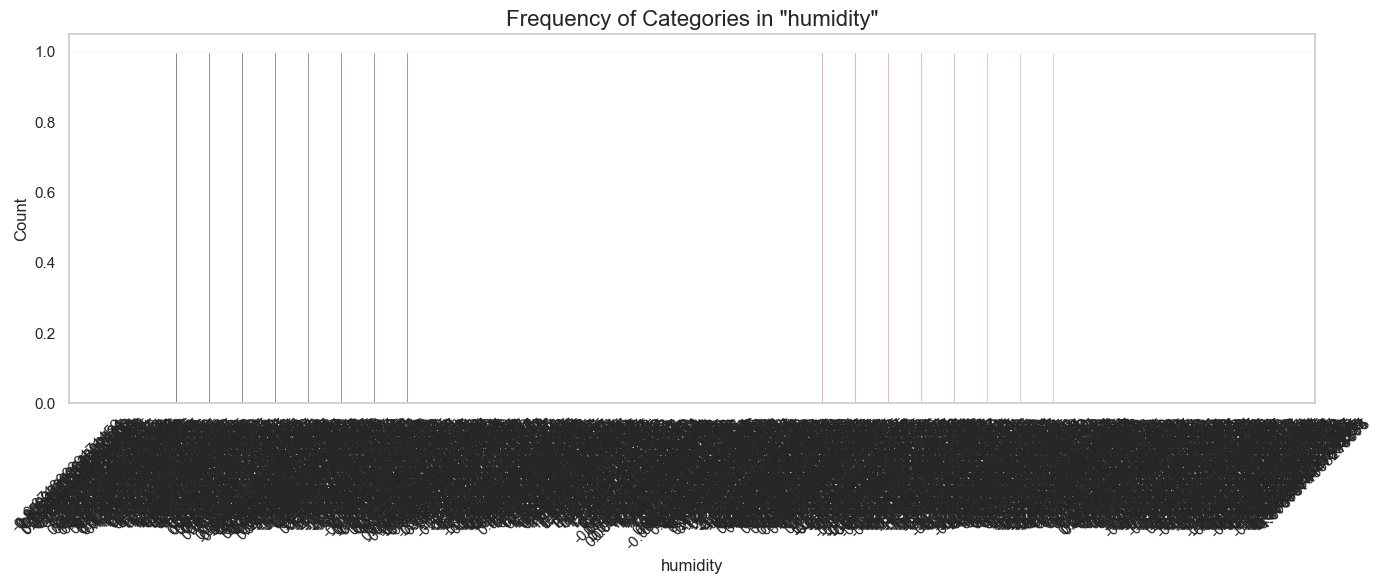

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


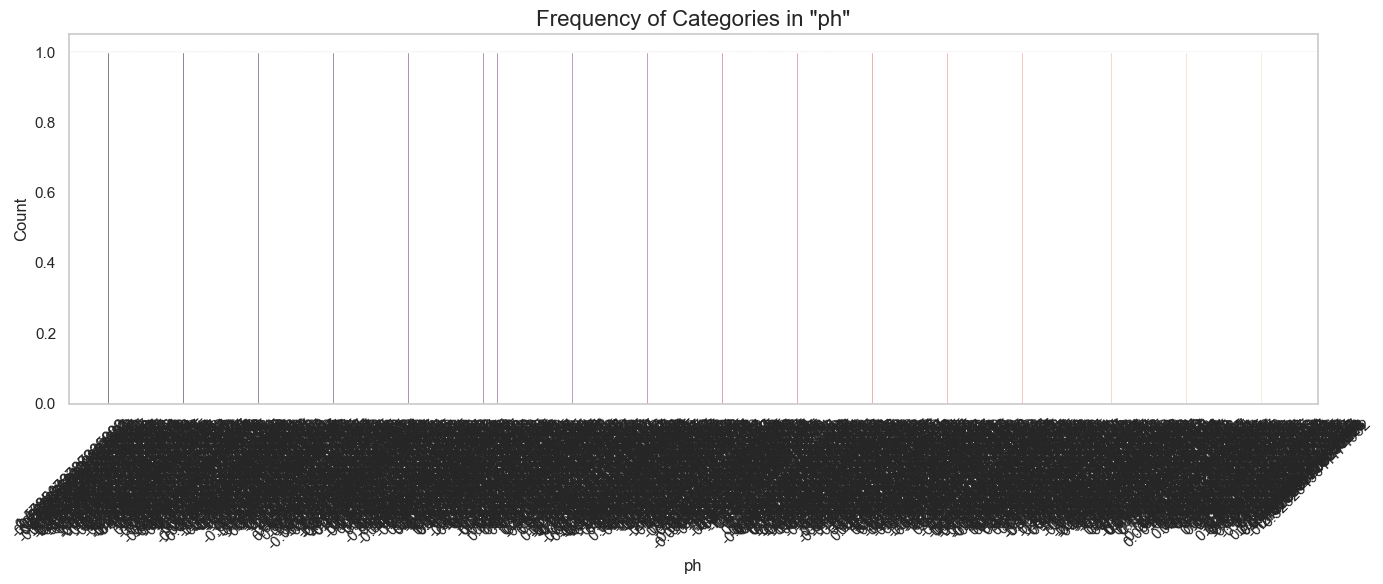

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\20266121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='magma')


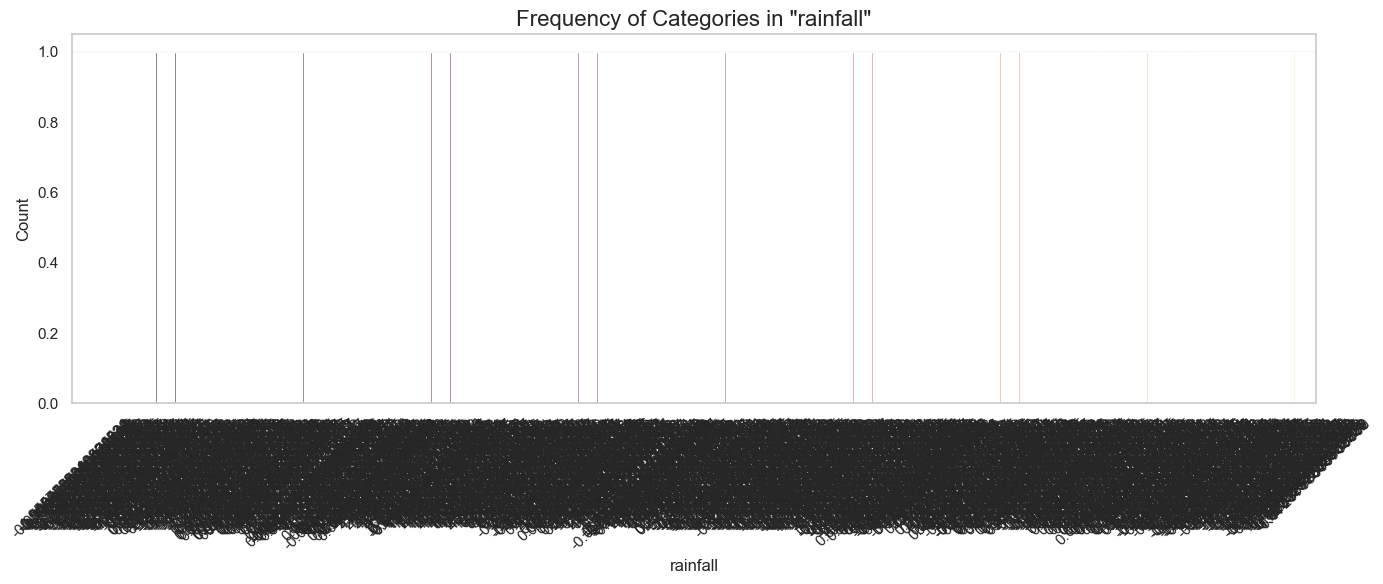

In [ ]:
# Set style
sns.set(style="whitegrid")

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Bar chart for each categorical column
for col in columns:
    plt.figure(figsize=(14, 6))
    order = df[col].value_counts().index  # Order by frequency
    sns.countplot(data=df, x=col, order=order, palette='magma')

    plt.title(f'Frequency of Categories in "{col}"', fontsize=16)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Bivariate and Multivariate Analysis

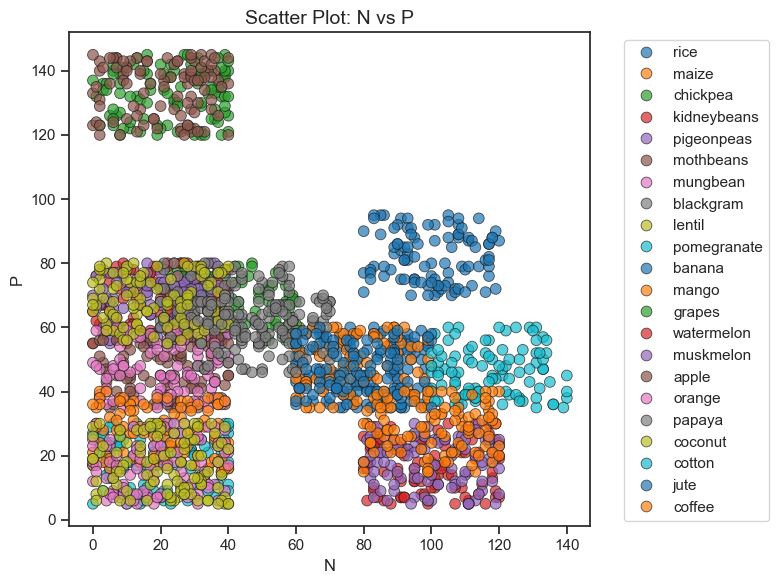

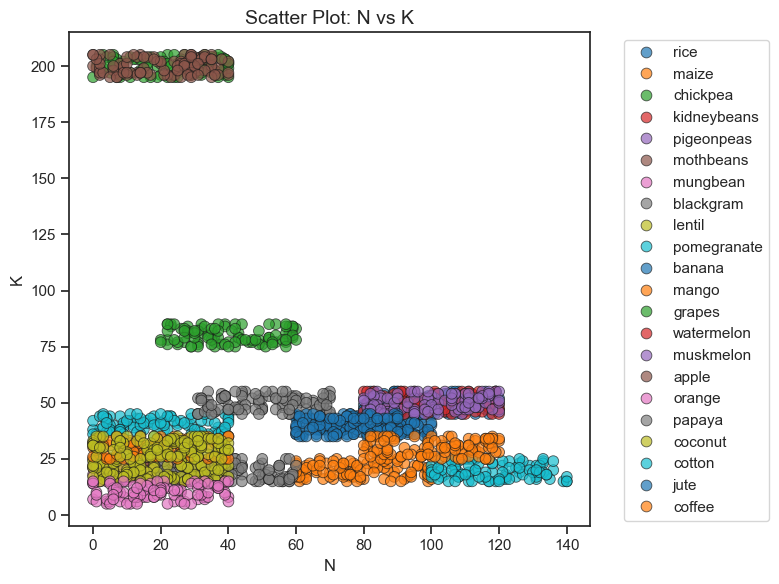

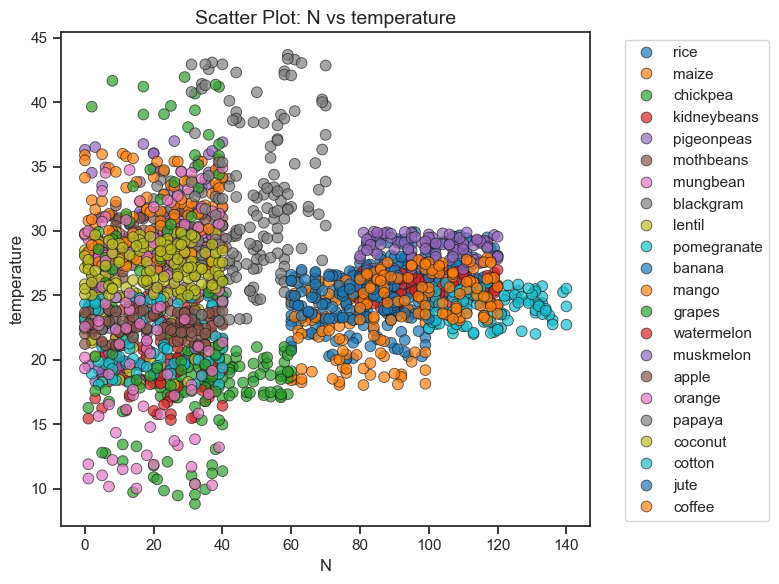

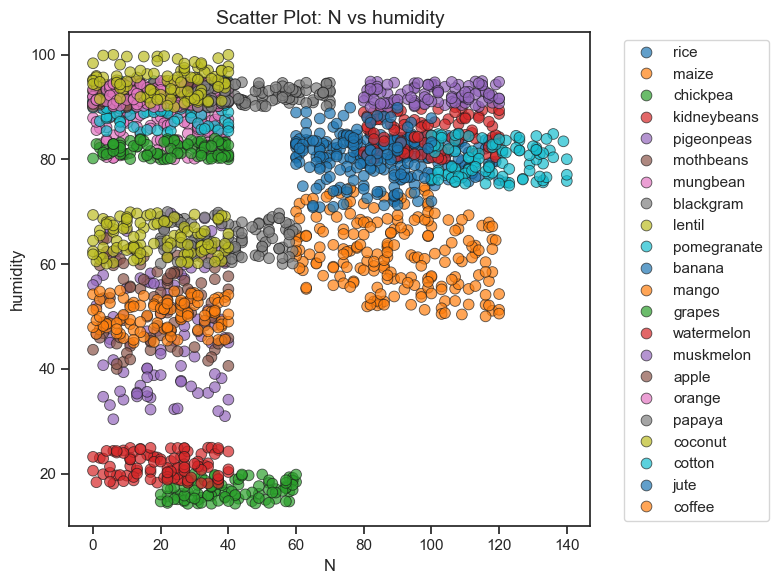

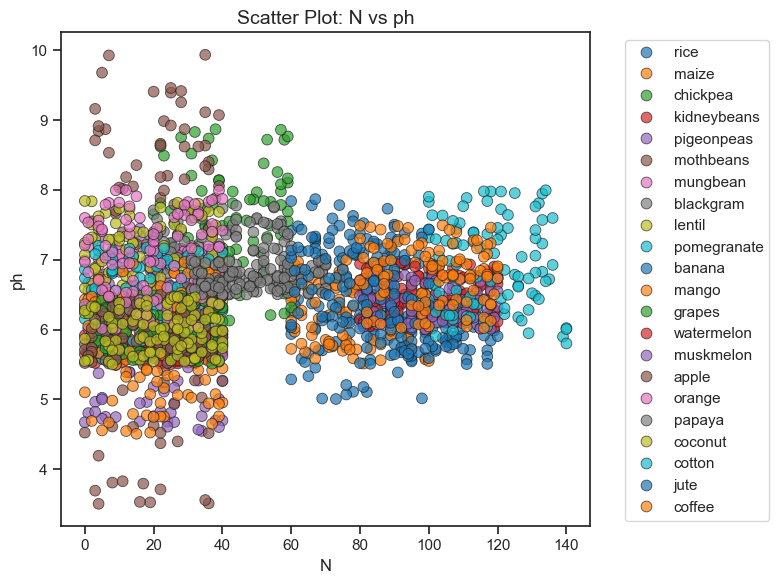

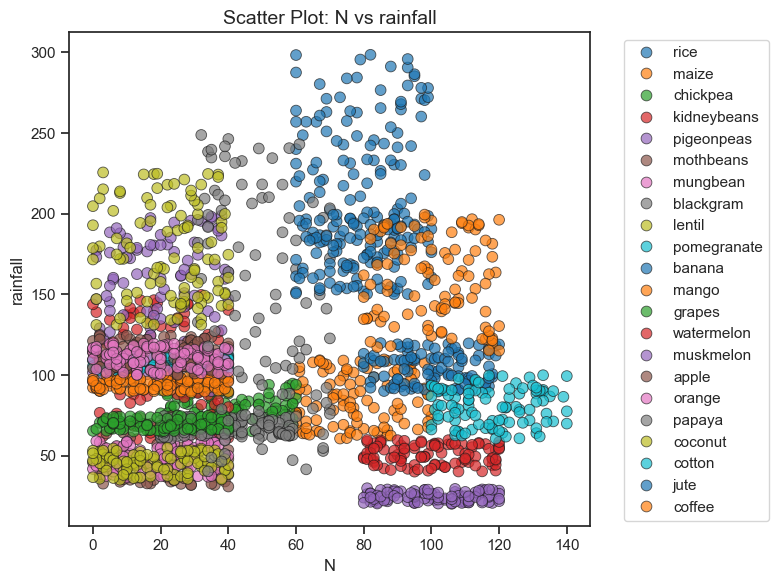

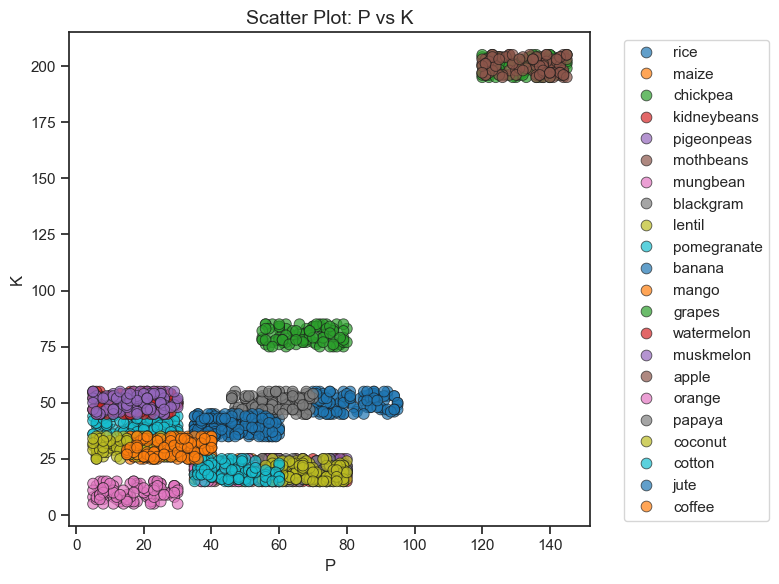

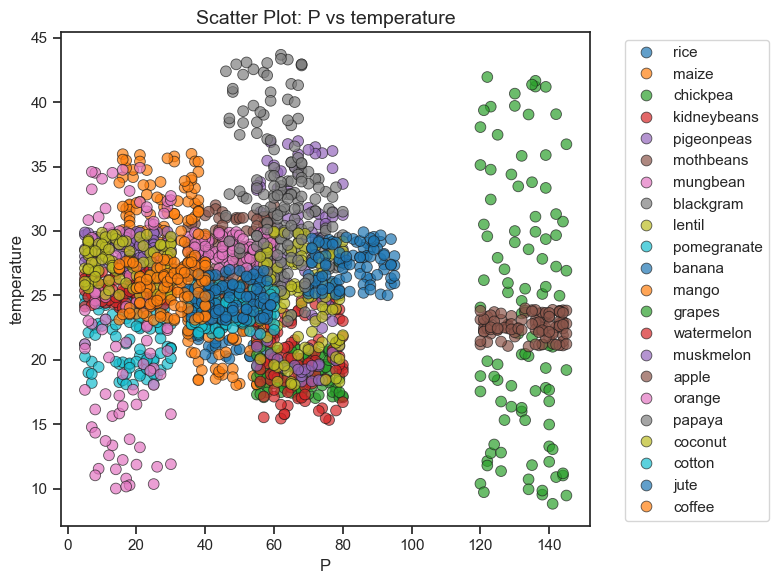

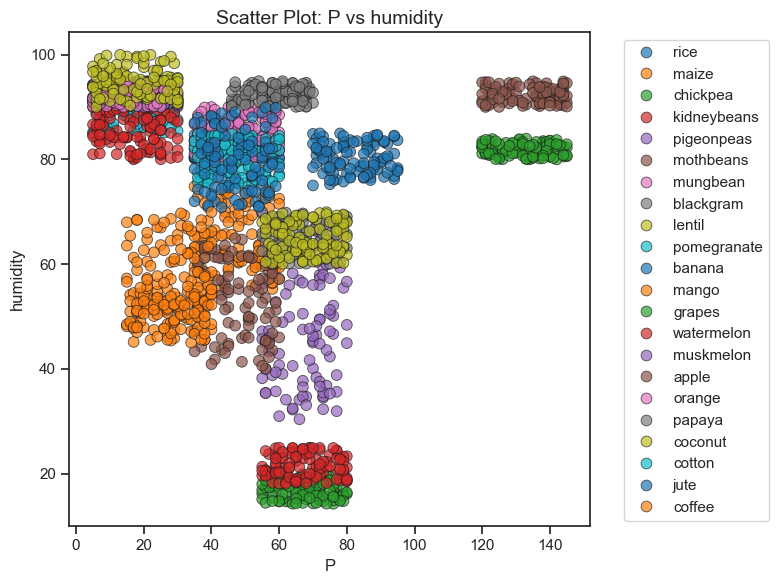

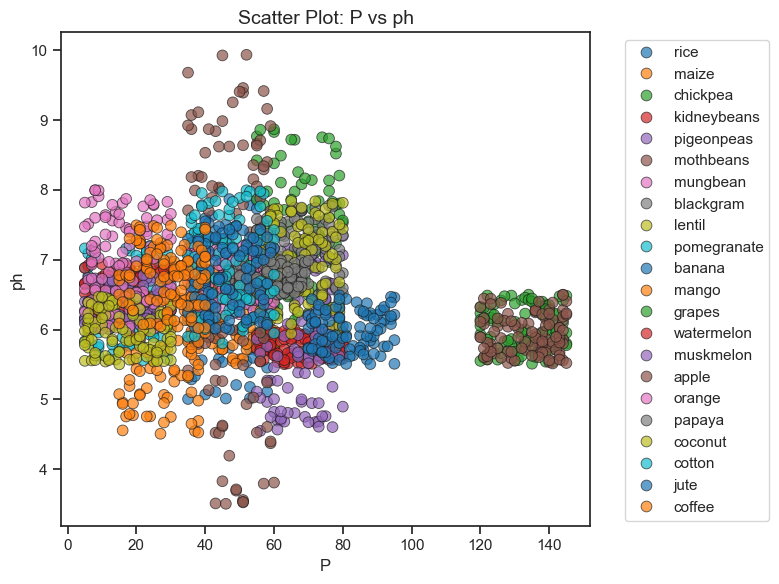

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Load dataset
df = pd.read_csv('crop_recommendation.csv')

# Drop unused columns
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Set plot style
sns.set(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)

# Identify continuous columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Scatter plots for all unique pairs of numeric columns (limit to a few for clarity)
pairs = list(combinations(numeric_cols, 2))[:10]  # First 10 pairs to avoid overload

for x, y in pairs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y, hue='label', palette='tab10', s=60, alpha=0.7, edgecolor='k')
    plt.title(f'Scatter Plot: {x} vs {y}', fontsize=14)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


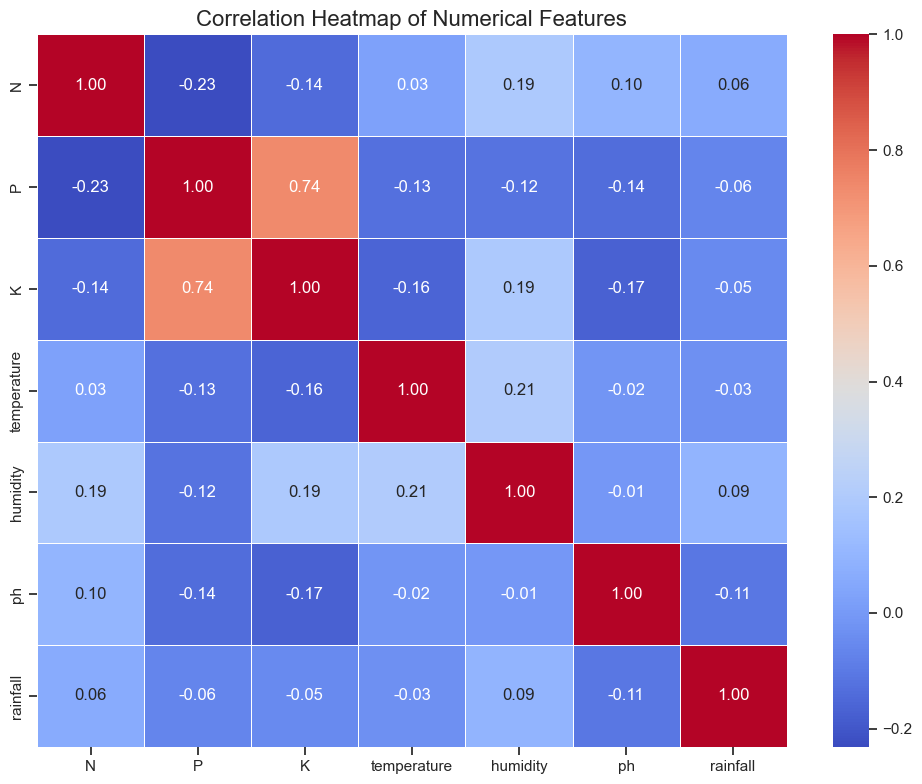

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Crop_recommendation12.csv')

# Drop unnecessary columns
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


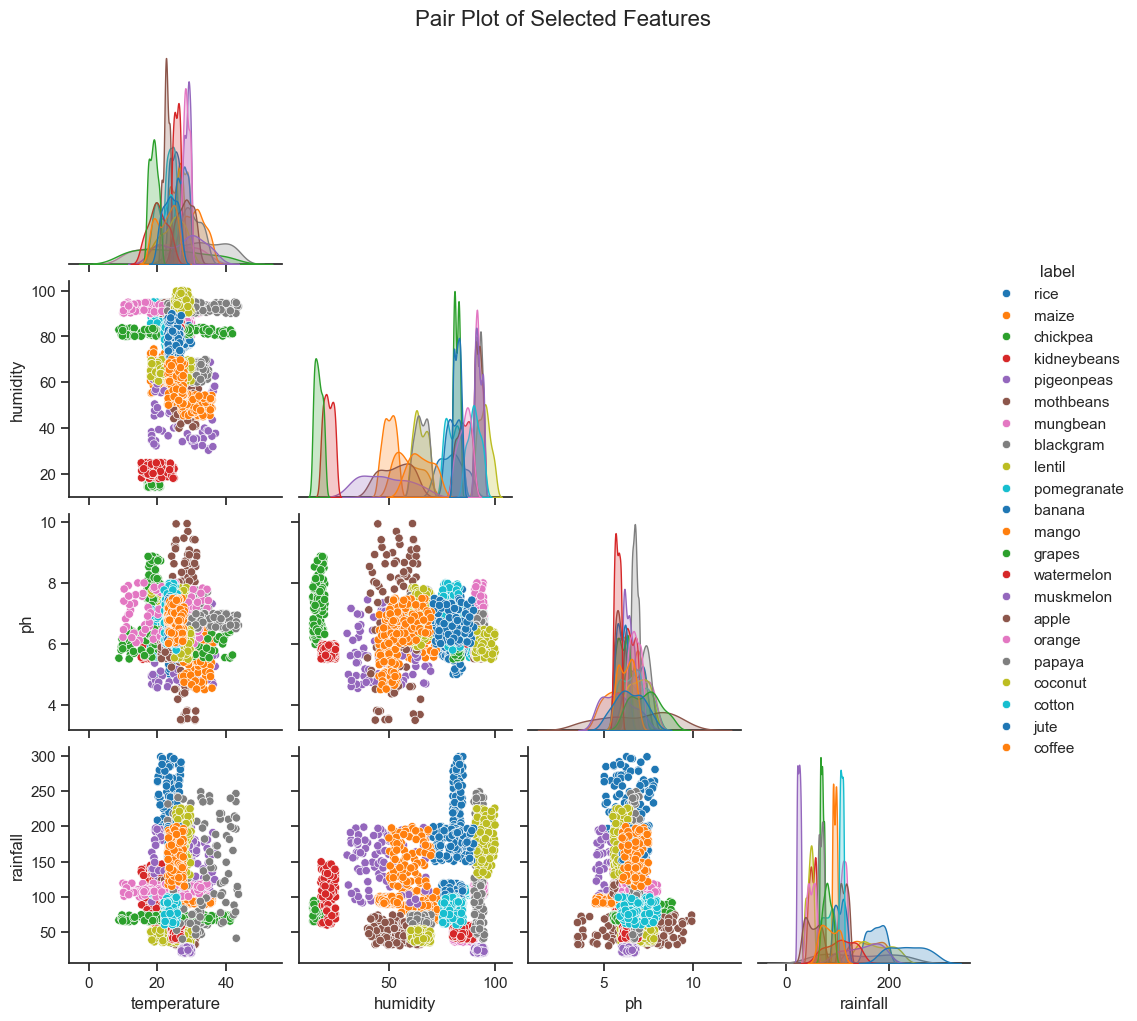

In [ ]:
import seaborn as sns

# Use only a subset of features + label to avoid clutter
selected_features = ['temperature', 'humidity', 'ph', 'rainfall', 'label']

# Create pair plot
sns.pairplot(df[selected_features], hue='label', palette='tab10', diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Selected Features', y=1.02, fontsize=16)
plt.show()


### Feature Analysis

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\3297443008.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')


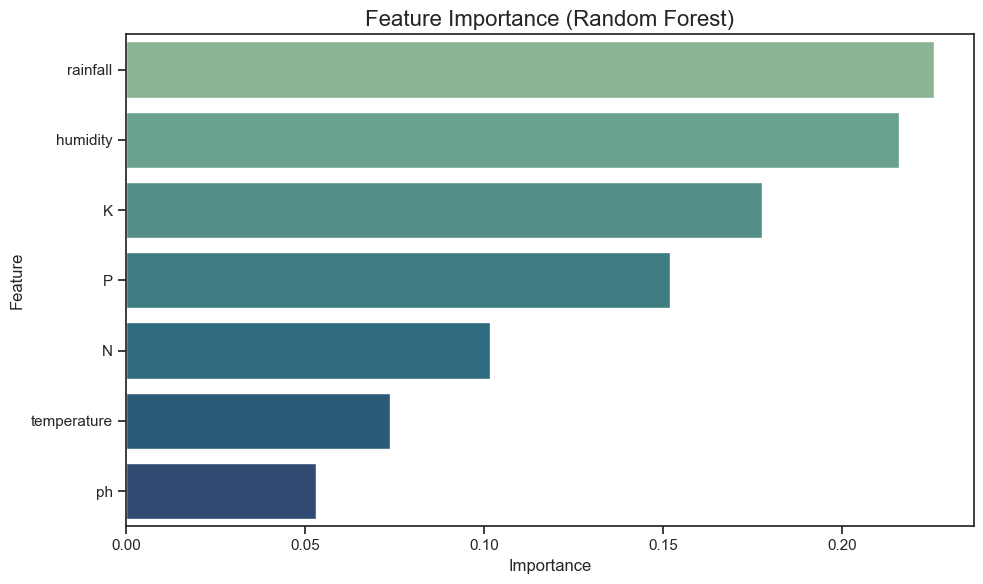

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('Crop_recommendation12.csv')
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Encode categorical target
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Features and target
X = df.drop(columns=['label', 'label_encoded'])
y = df['label_encoded']

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance (Random Forest)', fontsize=16)
plt.tight_layout()
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25008\2393517090.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x='Correlation', y='Feature', palette='coolwarm')


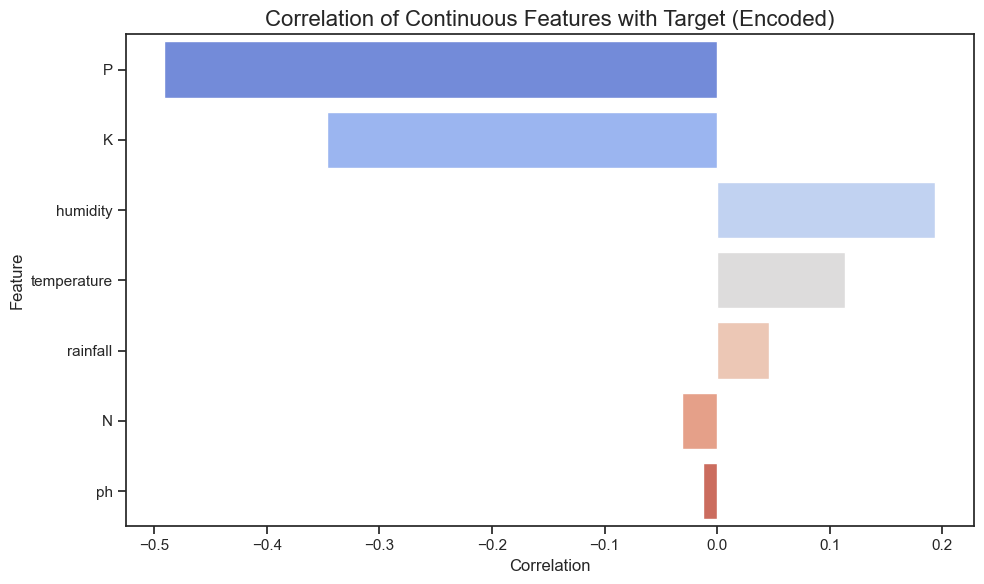

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load and clean data
df = pd.read_csv('Crop_recommendation12.csv')
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Check if 'label' exists
if 'label' not in df.columns:
    raise ValueError("The 'label' column is missing from the dataset.")

# Encode target variable
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Select continuous features, excluding 'label_encoded'
continuous_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'label_encoded']

# Compute correlation with target
correlations = df[continuous_cols].corrwith(df['label_encoded']).sort_values(key=abs, ascending=False)

# Convert to DataFrame for plotting
corr_df = correlations.reset_index()
corr_df.columns = ['Feature', 'Correlation']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_df, x='Correlation', y='Feature', palette='coolwarm')
plt.title('Correlation of Continuous Features with Target (Encoded)', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load and clean data
df = pd.read_csv('Crop_recommendation12.csv')
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Check if 'label' exists
if 'label' not in df.columns:
    raise ValueError("The 'label' column is missing from the dataset.")

# Encode target variable
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Identify categorical columns (excluding the original label column)
categorical_cols = df.select_dtypes(include=['object']).drop(columns='label').columns

# Function to compute group-wise statistics
def categorical_summary(df, categorical_cols, target_col='label_encoded'):
    summaries = {}
    for col in categorical_cols:
        # Group by the categorical feature and calculate summary stats for the target
        summary = df.groupby(col)[target_col].agg(['mean', 'count', 'std']).reset_index()
        summaries[col] = summary
    return summaries

# Generate summaries
summary_dict = categorical_summary(df, categorical_cols)

# Display summaries and plots
for col, summary in summary_dict.items():
    print(f"Summary for '{col}':")
    print(summary)
    print("\n")

    # Plot mean of the target variable for each category level
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary, x=col, y='mean', palette='viridis')
    plt.title(f'Mean of Target Variable per Level of {col}', fontsize=16)
    plt.ylabel('Mean Encoded Target')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Index([], dtype='object')


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load and clean data
df = pd.read_csv('Crop_recommendation12.csv')
df = df.drop(columns=["Unnamed: 8", "Unnamed: 9"], errors='ignore')

# Encode target variable
if 'label' not in df.columns:
    raise ValueError("The 'label' column is missing from the dataset.")
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.drop('label')

# Create a function to generate group-wise statistics
def categorical_summary(df, categorical_cols, target_col='label_encoded'):
    summaries = {}
    
    for col in categorical_cols:
        # Group by the categorical feature and calculate summary statistics for the target
        summary = df.groupby(col)[target_col].agg(['mean', 'count', 'std']).reset_index()
        summaries[col] = summary
    
    return summaries

# Get group-wise statistical summaries
summary_dict = categorical_summary(df, categorical_cols)

# Print and plot the summaries
for col, summary in summary_dict.items():
    print(f"Summary for {col}:")
    print(summary)
    print("\n")

    # Visualizing the mean target for each category level
    plt.figure(figsize=(10, 6))
    sns.barplot(x=col, y='mean', data=summary, palette='viridis')
    plt.title(f'Mean of Encoded Target for Different Levels of {col}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Deliverable 2

## Model Training and Evaluation

### Feature Selection

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load data
df = pd.read_csv('/kaggle/input/crop-recommendation-csv/crop_recommendation.csv')  

In [ ]:
# Encode target labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [ ]:
# Features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
# Feature importances
importances = rf.feature_importances_
feature_names = X.columns

In [ ]:
# Create a DataFrame for better visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

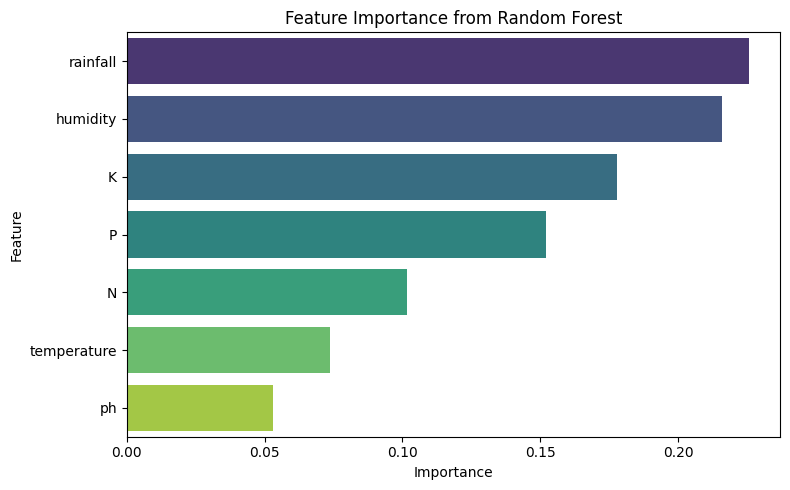

In [ ]:
# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

Although pH and temperature are the least influential, all features contribute meaningfully (>0.05), so we’ll keep all 7 for model training and won't drop any. 

### Model Selection and Training

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load dataset
df = pd.read_csv("data/crop_recommendation.csv")

# Feature matrix and labels
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#### Machine Learning Model (RandomForestClassifier)

In [ ]:
# Raw Features
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_ml, y_train_ml)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions and evaluation
y_pred_ml = rf.predict(X_test_ml)

In [ ]:
# Classification Report
print("Random Forest Classification Report:\n")
print(classification_report(y_test_ml, y_pred_ml, target_names=le.classes_))

Random Forest Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00

<Figure size 1200x800 with 0 Axes>

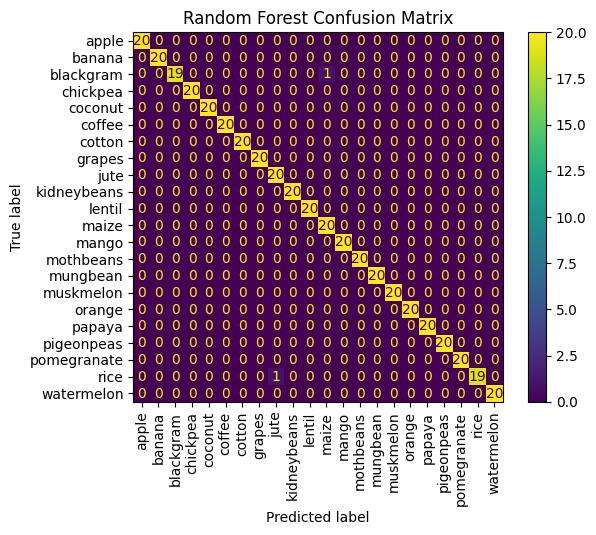

In [ ]:
# Confusion Matrix
plt.figure(figsize=(12, 8))
ConfusionMatrixDisplay.from_predictions(y_test_ml, y_pred_ml, display_labels=le.classes_, xticks_rotation=90)
plt.title("Random Forest Confusion Matrix")
plt.show()

#### Deep Learning Model (Feed Forward MLP)

In [ ]:
# Scaled + One-Hot
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_categorical = to_categorical(y_encoded)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
# Define model
model = Sequential([
    Dense(128, input_dim=7, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-02 20:21:55.591028: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
# Train model
history = model.fit(X_train_dl, y_train_dl, validation_data=(X_test_dl, y_test_dl), epochs=50, batch_size=32, verbose=0)

In [ ]:
# Evaluate model
loss, accuracy = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\nDL Model Accuracy: {accuracy:.4f}")


DL Model Accuracy: 0.9818


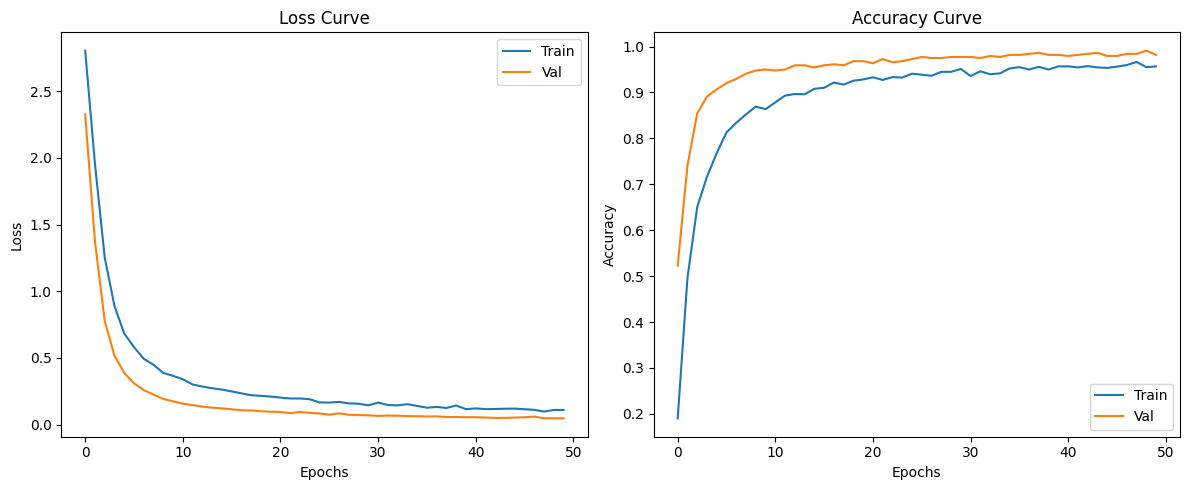

In [ ]:
# Plot loss/accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Predictions and class labels
y_pred_dl = model.predict(X_test_dl)
y_pred_classes = np.argmax(y_pred_dl, axis=1)
y_true_classes = np.argmax(y_test_dl, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# Classification Report
print("Deep Learning Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

Deep Learning Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.87      1.00      0.93        20
      grapes       1.00      1.00      1.00        20
        jute       0.86      0.95      0.90        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.85      0.92        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00

<Figure size 1200x800 with 0 Axes>

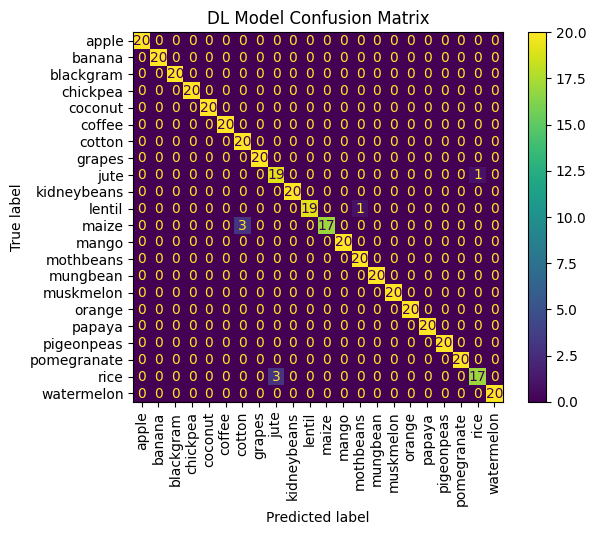

In [ ]:
# Confusion Matrix
plt.figure(figsize=(12, 8))
ConfusionMatrixDisplay.from_predictions(y_true_classes, y_pred_classes, display_labels=le.classes_, xticks_rotation=90)
plt.title("DL Model Confusion Matrix")
plt.show()

### Saving our models

In [ ]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
model.save("crop_recommendation_model.h5")